In [28]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import warnings
import scipy.ndimage as ndimage
from scipy import stats

sns.set(style="ticks", palette="Set2", context="notebook", rc={'axes.formatter.limits': (-3, 3)})
warnings.filterwarnings(action='ignore')
from sklearn.linear_model import LinearRegression
import pandas as pd

In [29]:
conversion_df = pl.read_csv("external_data/metalloproteome_exp_conversion.csv")

end_values = conversion_df["End"].unique().to_list()
index_values = conversion_df["Index"].unique().to_list()

end_dict = {end: i for i, end in enumerate(end_values)}
index_dict = {index: i for i, index in enumerate(index_values)}

conversion_df = conversion_df.with_columns(x=pl.col("End").replace(end_dict))
conversion_df = conversion_df.with_columns(y=pl.col("Index").replace(index_dict))

conversion_df = conversion_df.drop(["Start", "End", "Index"])
gene_df = pl.read_csv("data/accession_gene_dict.csv")
gene_dict = dict(zip(gene_df["Accession Number"], gene_df["Gene Name"]))
prot_df_raw = pl.read_csv('external_data/metalloproteome_proteins.csv')

prot_df = prot_df_raw.drop(["#", "Visible?", "Starred?", "Molecular Weight", "Taxonomy"])
prot_df = prot_df.with_columns(Gene=pl.col("Accession Number").replace(gene_dict))
prot_df = prot_df.drop(["Identified Proteins (1235)", "Accession Number"])
prot_df = prot_df.unique(subset=["Gene"], maintain_order=True)

prot_exp_names = list(prot_df.columns)[:-1]
gene_names = prot_df["Gene"].to_list()

prot_df = prot_df.drop(["Gene"]).transpose()
prot_df.columns = gene_names
prot_df = prot_df.with_columns(pl.Series(name="Experiment", values=prot_exp_names))
prot_df = prot_df.join(conversion_df, on="Experiment")
metal_df = pl.read_csv('external_data/metalloproteome_metals.csv')
metal_df = metal_df.drop([col for col in metal_df.columns if col.startswith("_dupli")])
metal_df = metal_df.drop([col for col in metal_df.columns if len(col) < 2])

metals = metal_df.columns[1:]

metal_join_df = metal_df.join(conversion_df, on="Experiment")

x_min = 3
y_min = 1
x_max = 15
y_max = 26

metal_join_df = metal_join_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
prot_df = prot_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))
# Zero out isolated protein signals with no neighboring support
footprint = np.array([[1,1,1],
                      [1,0,1],
                      [1,1,1]])

for protein in gene_names:
    prot_pivot = prot_df.pivot(values=protein, index="x", on="y").to_numpy()[:, 1:]

    prot_mask = prot_pivot > 0

    f = lambda x: x.sum()

    results = ndimage.generic_filter(prot_mask, f, footprint=footprint, mode="constant", cval=0)

    prot_pivot_true_mask = prot_mask & results

    if prot_pivot_true_mask.sum() > 0:
        prot_pivot[~prot_pivot_true_mask] = 0

    prot_df = prot_df.with_columns(pl.Series(name=protein, values=prot_pivot.flatten()))
# Replace extreme outlier wells with per-metal median values
problem_wells = [[11, 7], [12, 7], [9, 21]]

for metal in metals:
    metal_pivot = metal_join_df.pivot(values=metal, index="x", on="y").to_numpy()[:, 1:]

    for well in problem_wells:
        metal_pivot[well[0], well[1]] = np.median(metal_pivot)

    metal_join_df = metal_join_df.with_columns(pl.Series(name=metal, values=metal_pivot.flatten()))
gene = "deoB"

# Match element colors to final_paper_validation.ipynb (Set2, order: Fe Zn Mn Cu Mo Ni Co Cr)
_set2 = sns.color_palette("Set2")
element_palette = {
    "Fe": _set2[0], "Zn": _set2[1], "Mn": _set2[2], "Cu": _set2[3],
    "Mo": _set2[4], "Ni": _set2[5], "Co": _set2[6], "Cr": _set2[7],
}
isotope_display_dict = {
    "56Fe": "Fe", "66Zn": "Zn", "55Mn": "Mn", "63Cu": "Cu",
    "60Ni": "Ni", "59Co": "Co", "52Cr": "Cr",
}
element_order = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

DeoB_subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

DeoB_subset = metal_join_df.select(["x", "y", "60Ni", "59Co", "63Cu","52Cr", "56Fe", "55Mn", "66Zn"]).join(DeoB_subset, on=["x", "y"], how="inner")

DeoB_subset = DeoB_subset.with_columns(pl.col(["60Ni", "59Co", "63Cu", "52Cr", "56Fe","55Mn", "66Zn", gene]))

DeoB_subset = DeoB_subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

DeoB_subset = DeoB_subset.with_columns(pl.col("Element").replace(isotope_display_dict))

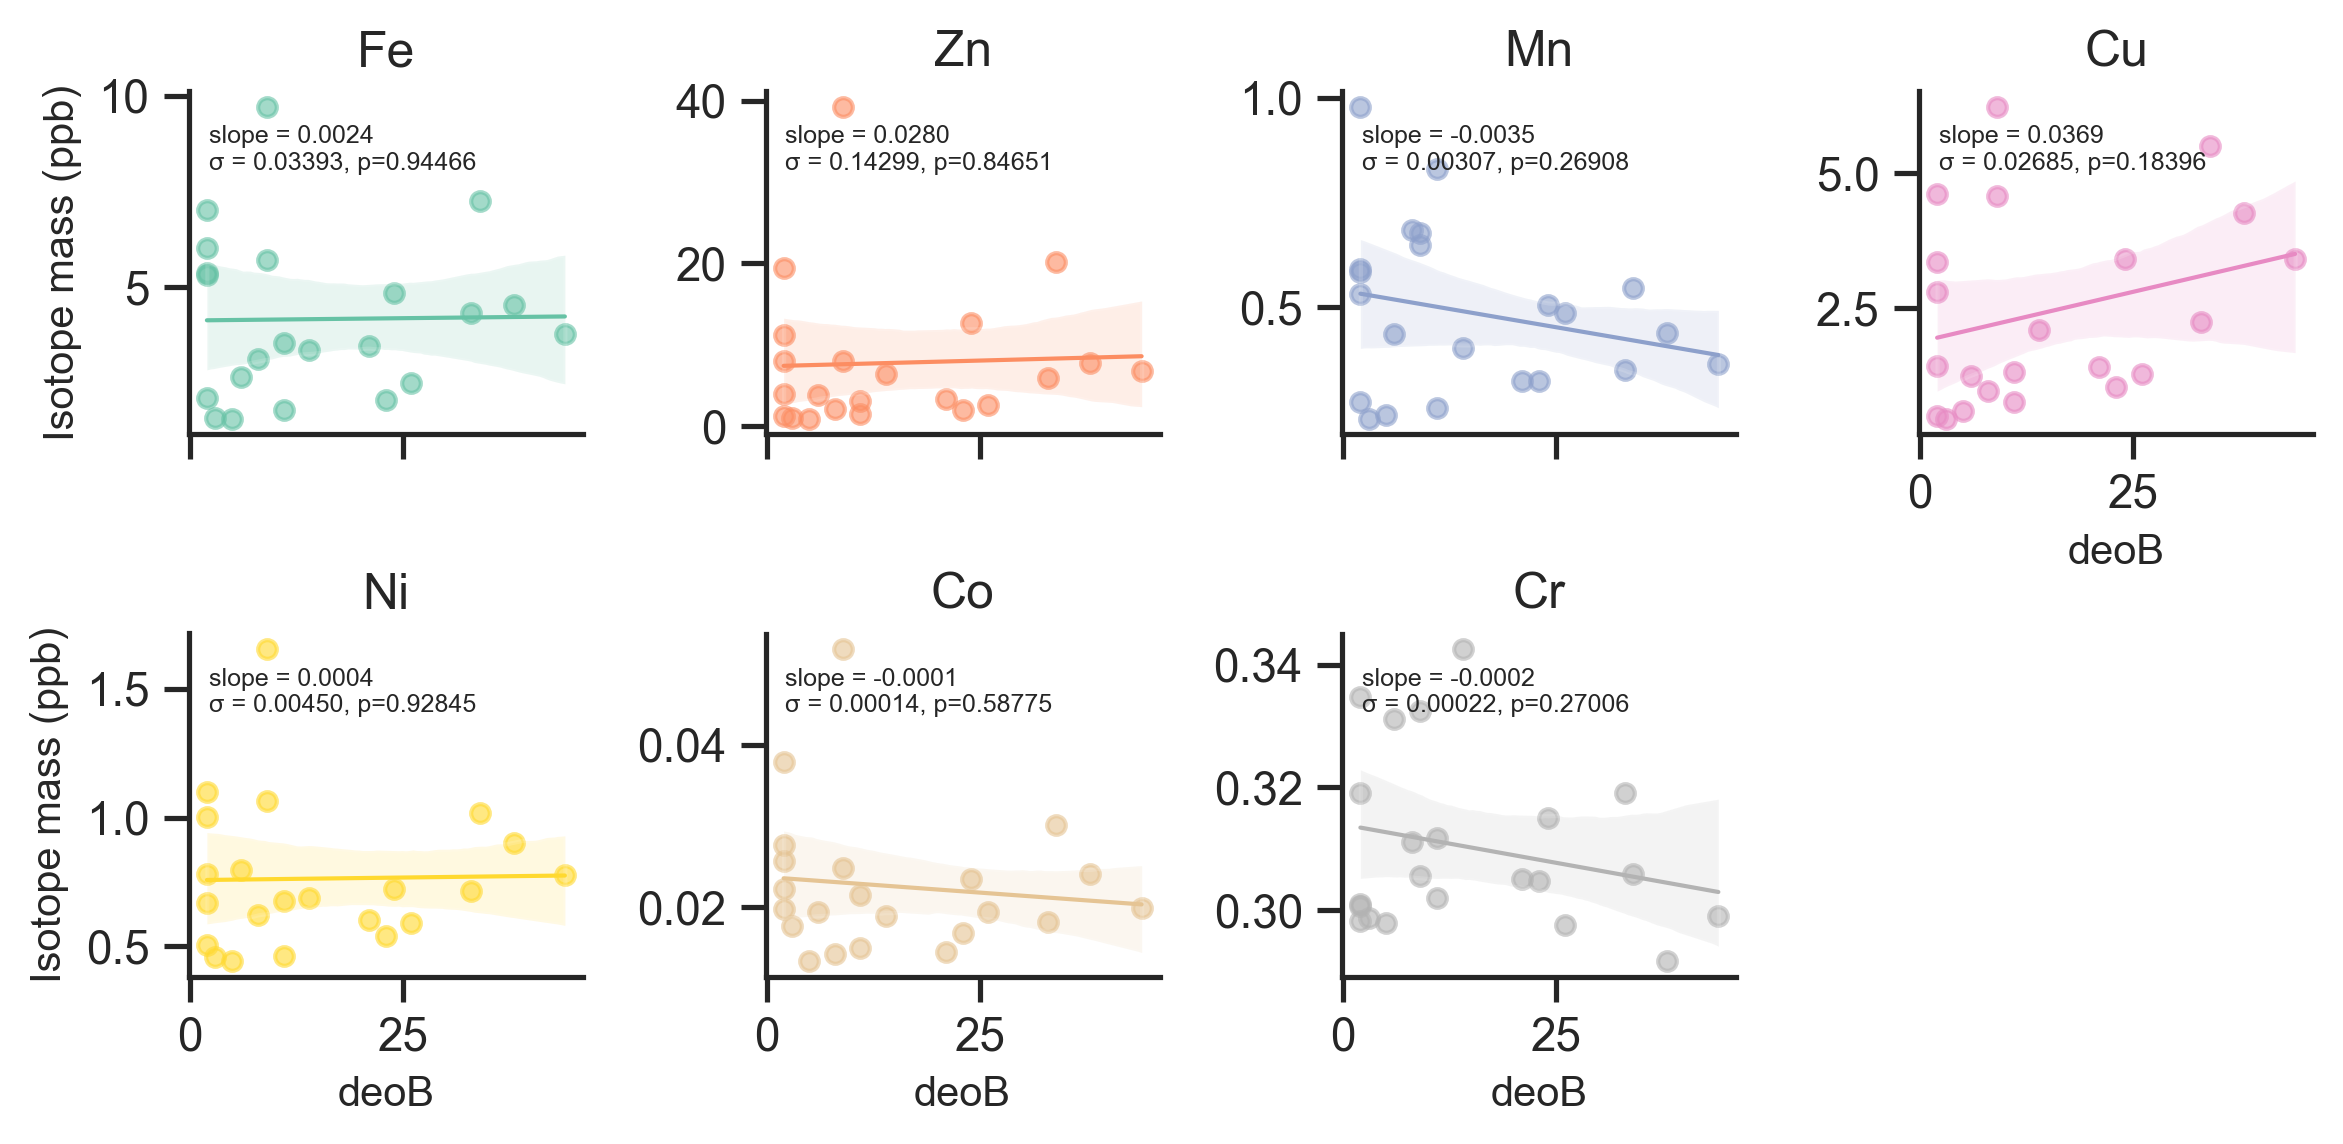

In [30]:
g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=DeoB_subset, 
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4, 
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_slope_std(data, **kws):
    x = data[gene]
    y = data["Isotope mass (ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    t = slope / slope_std
    p = 2 * (1 - stats.t.cdf(np.abs(t), df=len(x)-2))
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nσ = {slope_std:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

# Apply annotations
g.map_dataframe(annotate_slope_std)

# Adjust labels
g.set_axis_labels(gene, "Isotope mass (ppb)", fontsize=10)
g.set_titles("{col_name}", fontsize=12)

# Save and show
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_isotope_correlations.svg", 
#             format='svg', bbox_inches='tight')
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_isotope_correlations.png", 
#             format='png', bbox_inches='tight')

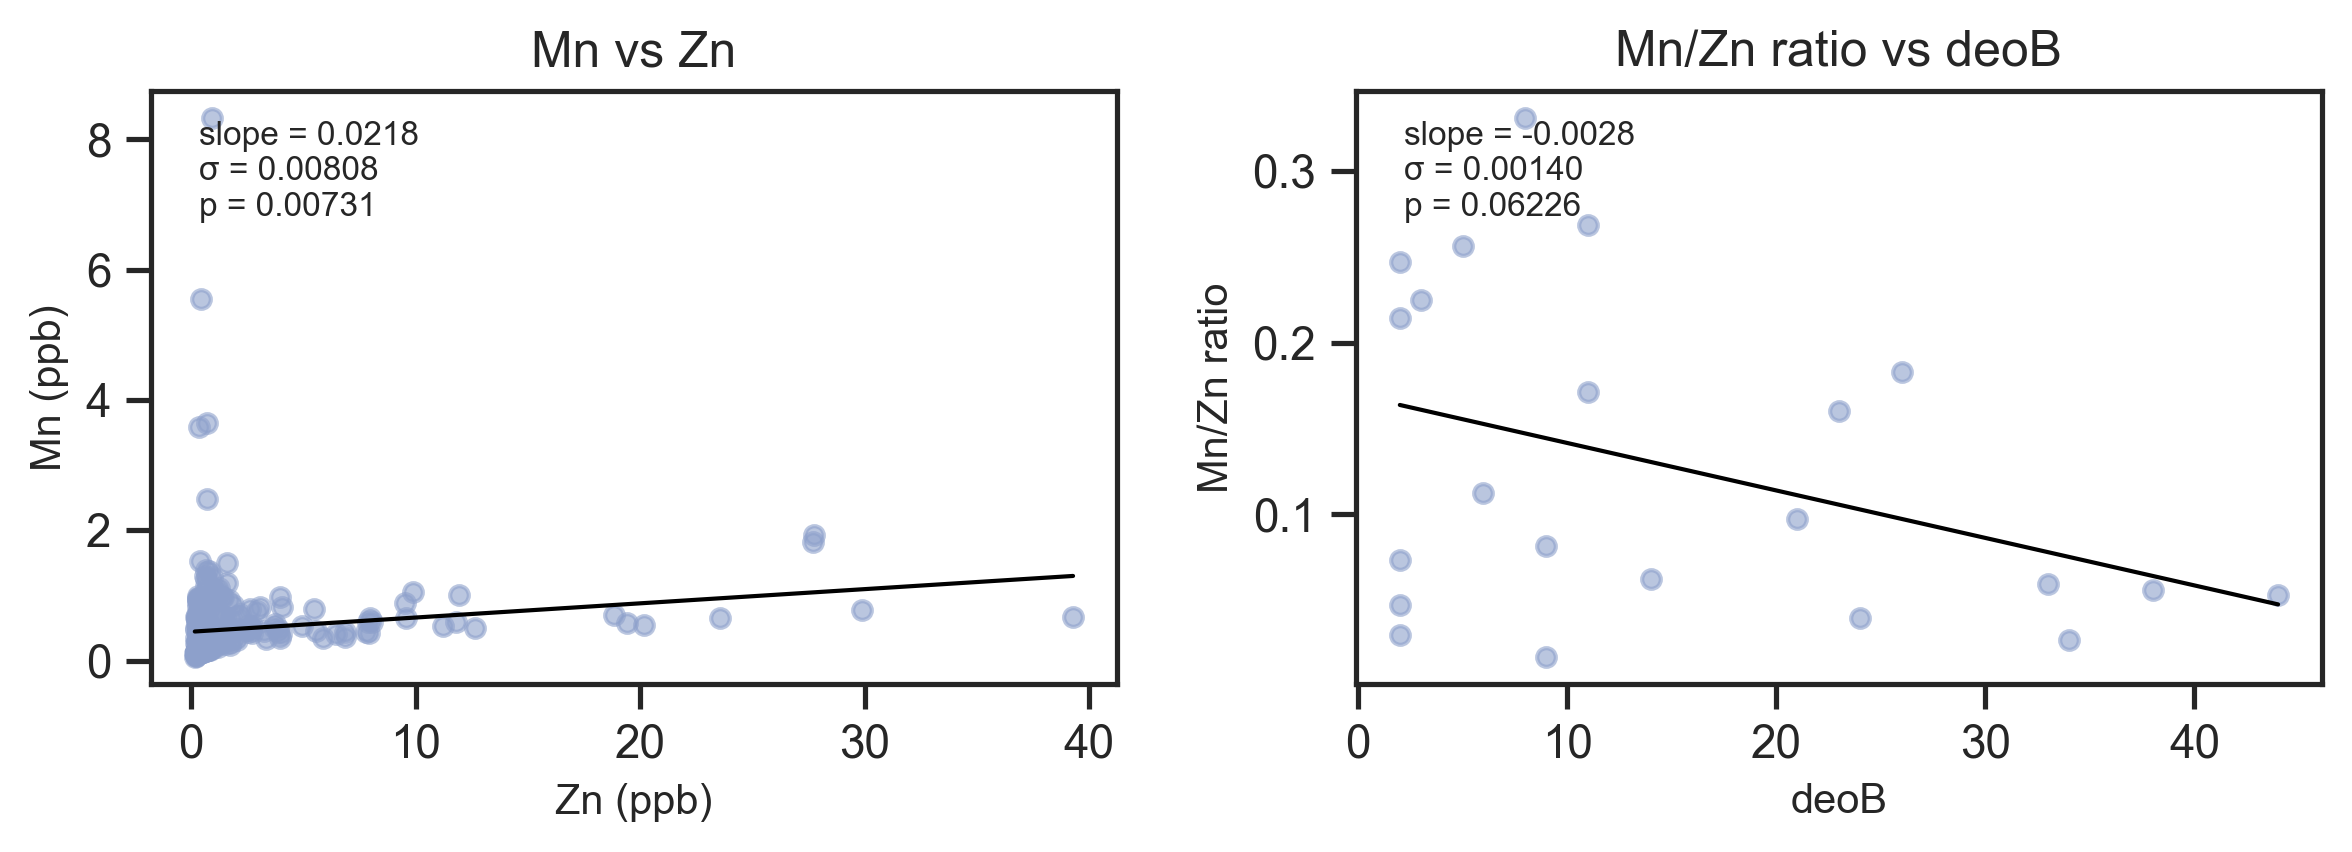

In [31]:
# Plot 1: Mn counts vs Zn counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

# Get data for Mn vs Zn plot
MnZn_data = metal_join_df.select(["x", "y", "55Mn", "66Zn"]).filter(
    (pl.col("55Mn").is_not_null()) & (pl.col("66Zn").is_not_null())
)

mn_vals = MnZn_data["55Mn"].to_numpy()
zn_vals = MnZn_data["66Zn"].to_numpy()

# Plot Mn vs Zn
ax1.scatter(zn_vals, mn_vals, alpha=0.6, s=20, color=element_palette["Mn"])
ax1.set_xlabel("Zn (ppb)", fontsize=10)
ax1.set_ylabel("Mn (ppb)", fontsize=10)
ax1.set_title("Mn vs Zn", fontsize=12)

# Add regression line
slope, intercept = np.polyfit(zn_vals, mn_vals, 1)
x_line = np.array([zn_vals.min(), zn_vals.max()])
ax1.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1)

# Calculate statistics
resid_std = np.std(mn_vals - (slope * zn_vals + intercept))
slope_std = resid_std / np.sqrt(np.sum((zn_vals - np.mean(zn_vals))**2))
t = slope / slope_std
p = 2 * (1 - stats.t.cdf(np.abs(t), df=len(zn_vals)-2))

ax1.text(0.05, 0.95, f"slope = {slope:.4f}\nσ = {slope_std:.5f}\np = {p:.5f}", 
         transform=ax1.transAxes, fontsize=8, va="top")

# Plot 2: Mn/Zn ratio vs DeoB
# Get DeoB data and merge with metal data
ratio_data = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)
ratio_data = metal_join_df.select(["x", "y", "55Mn", "66Zn"]).join(ratio_data, on=["x", "y"], how="inner")

# Calculate Mn/Zn ratio
ratio_data = ratio_data.with_columns(
    (pl.col("55Mn") / pl.col("66Zn")).alias("Mn_Zn_ratio")
)

# Filter out infinite/nan values
ratio_data = ratio_data.filter(
    pl.col("Mn_Zn_ratio").is_finite() & pl.col("Mn_Zn_ratio").is_not_null()
)

ratio_vals = ratio_data["Mn_Zn_ratio"].to_numpy()
protein_vals = ratio_data[gene].to_numpy()

# Plot Mn/Zn ratio vs protein
ax2.scatter(protein_vals, ratio_vals, alpha=0.6, s=20, color=element_palette["Mn"])
ax2.set_xlabel(f"{gene}", fontsize=10)
ax2.set_ylabel("Mn/Zn ratio", fontsize=10)
ax2.set_title(f"Mn/Zn ratio vs {gene}", fontsize=12)

# Add regression line
slope2, intercept2 = np.polyfit(protein_vals, ratio_vals, 1)
x_line2 = np.array([protein_vals.min(), protein_vals.max()])
ax2.plot(x_line2, slope2 * x_line2 + intercept2, 'k-', linewidth=1)

# Calculate statistics
resid_std2 = np.std(ratio_vals - (slope2 * protein_vals + intercept2))
slope_std2 = resid_std2 / np.sqrt(np.sum((protein_vals - np.mean(protein_vals))**2))
t2 = slope2 / slope_std2
p2 = 2 * (1 - stats.t.cdf(np.abs(t2), df=len(protein_vals)-2))

ax2.text(0.05, 0.95, f"slope = {slope2:.4f}\nσ = {slope_std2:.5f}\np = {p2:.5f}", 
         transform=ax2.transAxes, fontsize=8, va="top")

plt.tight_layout()
plt.show()

# Optionally save the figure
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/Mn_Zn_analysis.svg", 
#             format='svg', bbox_inches='tight')
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/Mn_Zn_analysis.png", 
#             format='png', bbox_inches='tight')

# normalized values 

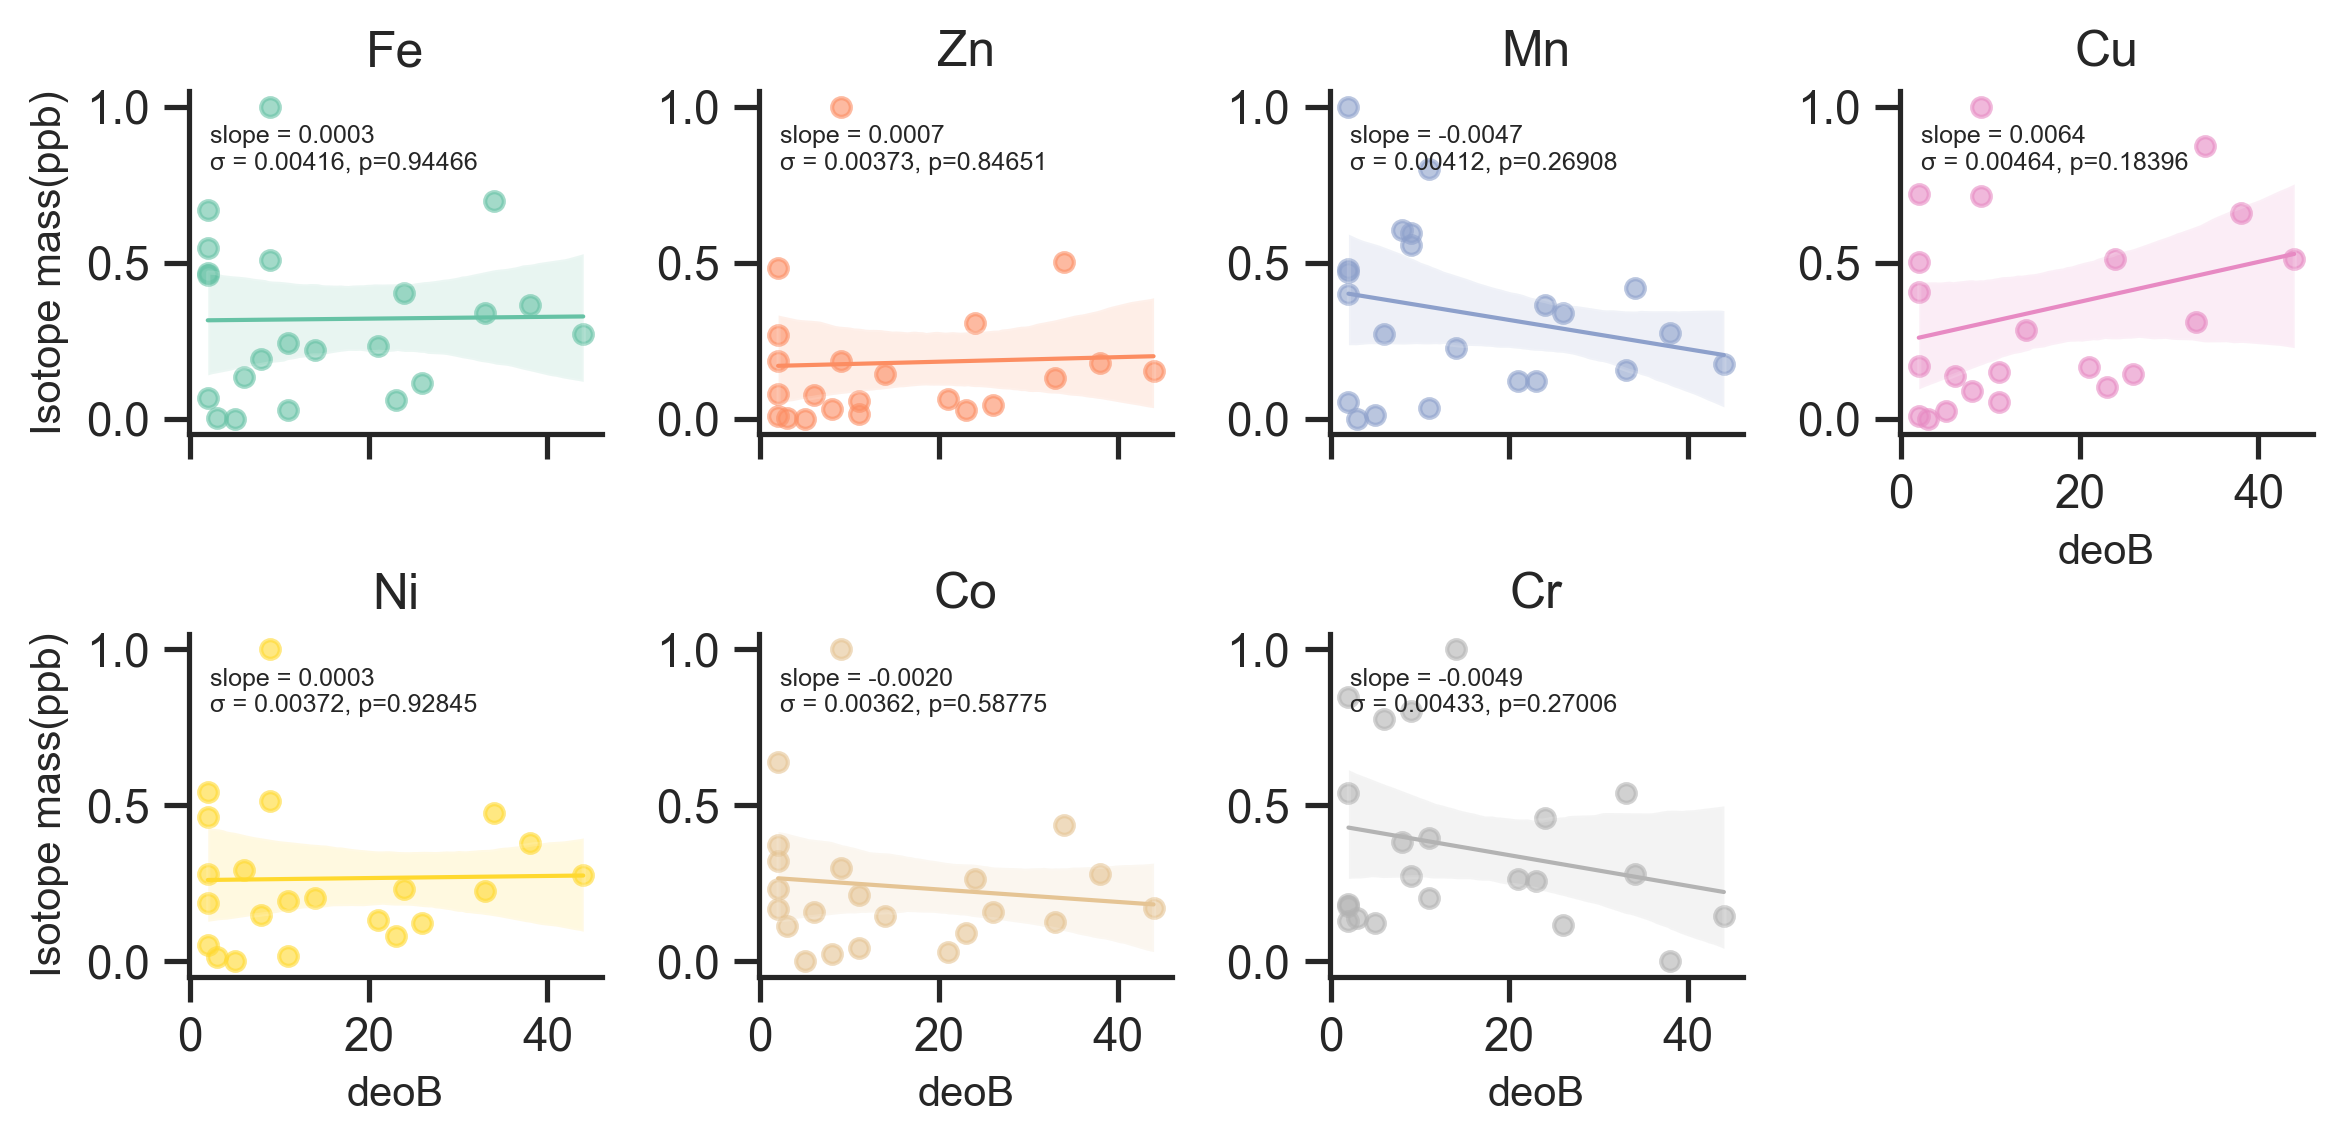

In [32]:
# Min-Max normalization (scales to 0-1 range)
DeoB_subset_norm = DeoB_subset.with_columns(
    ((pl.col("Isotope mass (ppb)") - pl.col("Isotope mass (ppb)").min().over("Element")) /
     (pl.col("Isotope mass (ppb)").max().over("Element") - pl.col("Isotope mass (ppb)").min().over("Element"))
    ).alias("Isotope mass(ppb)")
)

# Create the lmplot
g_norm = sns.lmplot(x=gene, y="Isotope mass(ppb)", hue="Element", data=DeoB_subset_norm, 
                    height=2.0, aspect=1,
                    col="Element", col_order=element_order, col_wrap=4, 
                    sharey=False, palette=element_palette,
                    scatter_kws={"alpha": 0.6, "s": 20},
                    line_kws={"linewidth": 1, "linestyle": "-"},
                    legend=False)

# Annotation function
def annotate_slope_std_norm(data, **kws):
    x = data[gene]
    y = data["Isotope mass(ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    t = slope / slope_std
    p = 2 * (1 - stats.t.cdf(np.abs(t), df=len(x)-2))
    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.4f}\nσ = {slope_std:.5f}, p={p:.5f}", 
            transform=ax.transAxes, fontsize=6, va="top")

# Apply annotations
g_norm.map_dataframe(annotate_slope_std_norm)

# Adjust labels
g_norm.set_axis_labels(gene, "Isotope mass(ppb)", fontsize=10)
g_norm.set_titles("{col_name}", fontsize=12)

# Save and show
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_isotope_correlations_normalized.svg", 
#             format='svg', bbox_inches='tight')
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_isotope_correlations_normalized.png", 
#             format='png', bbox_inches='tight')

In [33]:
def plot_normalized_metals_scatter(dataframe, metals, gene, element_palette, output_filename):
    metals_norm = (
        dataframe
        .filter(pl.col("Element").is_in(metals))
        .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
        .drop_nulls(subset=metals)
    )

    metal_values = {metal: metals_norm[metal].to_numpy() for metal in metals}

    if len(metals) != 2:
        raise ValueError("This function currently supports only two metals for scatter plotting.")

    metal1, metal2 = metals
    slope, intercept, r, p, se = stats.linregress(metal_values[metal1], metal_values[metal2])

    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(metal_values[metal1], metal_values[metal2], alpha=0.7, s=30, color=element_palette[metal2], edgecolors="none")
    x_line = np.linspace(metal_values[metal1].min(), metal_values[metal1].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="gray", lw=1.5, linestyle="--")
    ax.set_xlabel(f"{metal1} (normalized)", fontsize=10)
    ax.set_ylabel(f"{metal2} (normalized)", fontsize=10)
    ax.set_title(f"{metal2} vs {metal1} (normalized spectral counts)", fontsize=10)
    ax.text(0.05, 0.95, f"r = {r:.3f}\np = {p:.3e}", transform=ax.transAxes, fontsize=8, va="top")
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(output_filename, format="svg", bbox_inches="tight")
    plt.show()

In [34]:
# plot_normalized_metals_scatter(DeoB_subset_norm, ["Zn", "Fe"], gene, element_palette, f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_Fe_vs_Cr_normalized.svg")


# Avg signal (Zn, Fe, Mn) linear regression — all metals

In [35]:
# Pivot all 7 elements to wide format using the 0-1 normalized values from DeoB_subset_norm
all_elements = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

pivot_norm_all = (
    DeoB_subset_norm
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

# avg_signal = mean of the 0-1 normalized Zn, Fe, Mn values per well
pivot_norm_all = pivot_norm_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn")) / 3)
)

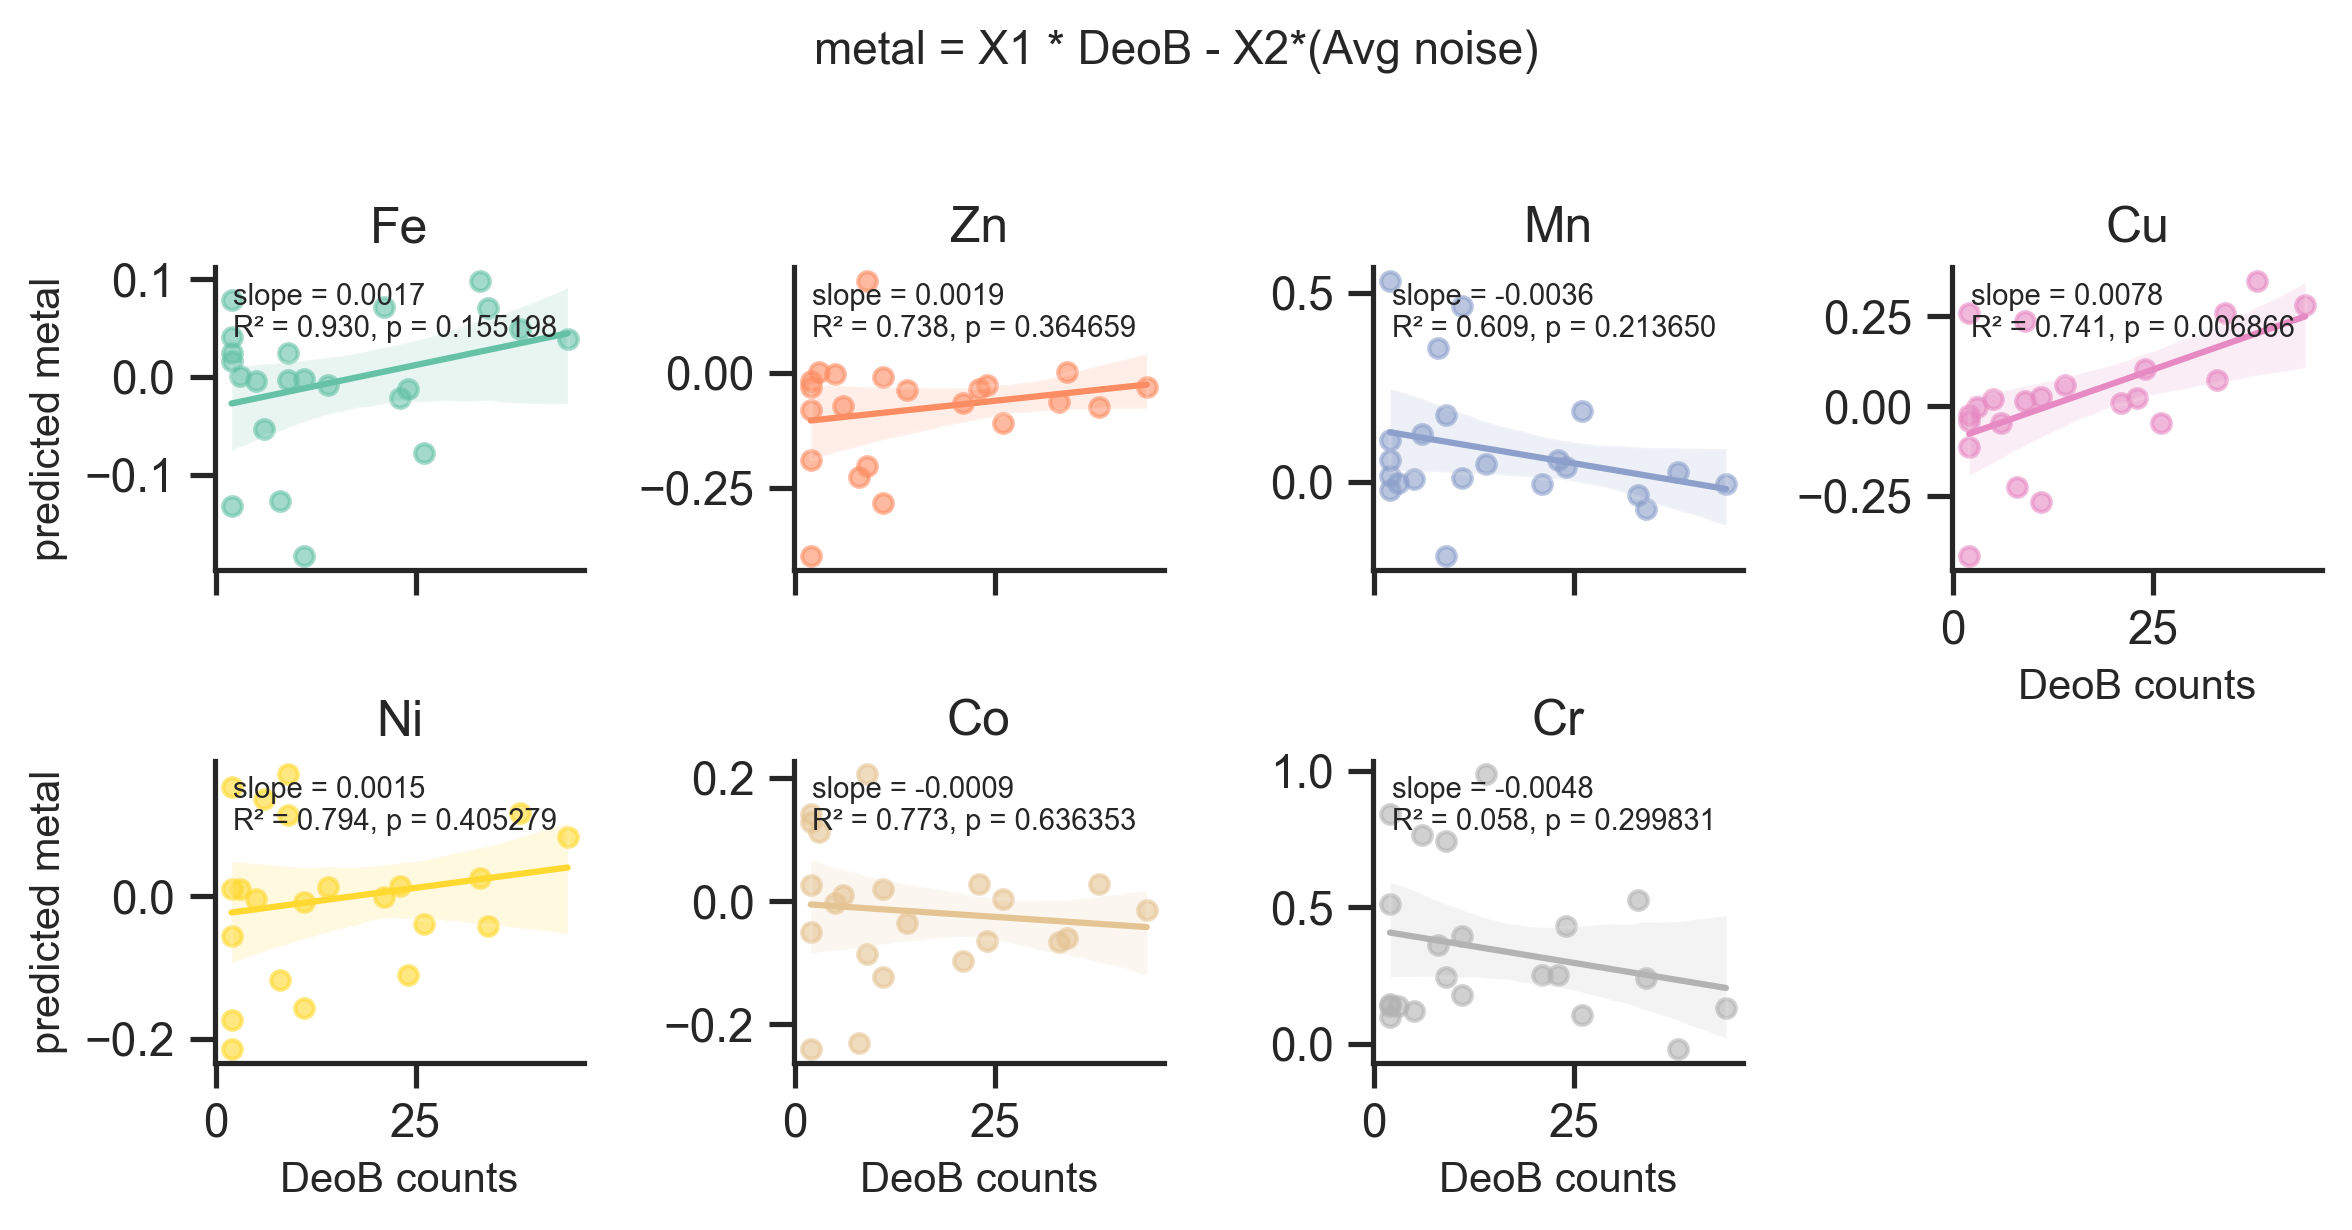

In [36]:
# Prepare data for all elements
plot_data_list = []
slopes = []
slope_ses = []
stats_dict = {}

for elem in element_order:
    df_pd = pivot_norm_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["DeoB", "avg_signal", "metal"]

    X = df_pd[["DeoB", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    X1, X2 = model.coef_

    # SE of X1 from multiple regression covariance matrix
    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])

    slopes.append(X1)
    slope_ses.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    _, _, r_c, p_c, _ = stats.linregress(df_pd["DeoB"].values, metal_corrected)

    # Store stats for annotation
    stats_dict[elem] = {"X1": X1, "r2": r2, "p_c": p_c}
    
    # Build combined dataframe
    plot_df = pd.DataFrame({
        "DeoB": df_pd["DeoB"], 
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list.append(plot_df)

# Combine all data
combined_plot_data = pd.concat(plot_data_list, ignore_index=True)

# Create the lmplot
g = sns.lmplot(x="DeoB", y="metal_corrected", hue="Element", data=combined_plot_data,
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4,
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1.5, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_stats(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {stats_info['p_c']:5f}",
            transform=ax.transAxes, fontsize=7, va="top")

# Apply annotations
g.map_dataframe(annotate_stats)

# Adjust labels
g.set_axis_labels("DeoB counts", "predicted metal", fontsize=10)
g.set_titles("{col_name}", fontsize=10)

# Add suptitle
g.figure.suptitle("metal = X1 * DeoB - X2*(Avg noise)", fontsize=11, y=1.02)

# Save and show
sns.despine()
plt.tight_layout()
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_lr_avgAll_signal.svg", 
#             format="svg", bbox_inches="tight")
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_lr_avgAll_signal.png", 
#             format="png", bbox_inches="tight")
plt.show()

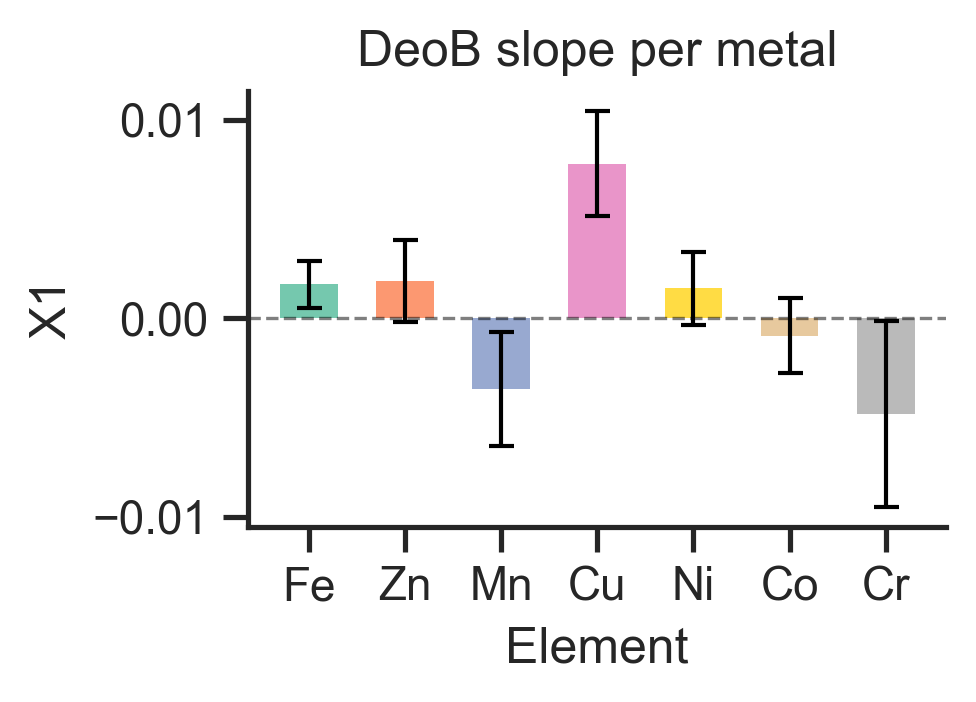

In [37]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

bar_colors = [element_palette[elem] for elem in element_order]
x_pos = np.arange(len(element_order))

ax.bar(x_pos, slopes, color=bar_colors, width=0.6, alpha=0.9,
       edgecolor="none")
ax.errorbar(x_pos, slopes, yerr=slope_ses,
            fmt="none", color="black", capsize=3, lw=1)
ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(element_order)
ax.set_xlabel("Element")
ax.set_ylabel("X1")
ax.set_title("DeoB slope per metal")

sns.despine()
plt.tight_layout()
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_slopes_barplot.svg", format="svg", bbox_inches="tight")
plt.show()

In [38]:
# Pivot all 7 elements to wide format using the 0-1 normalized values from DeoB_subset_norm
all_elements = ["Fe", "Zn", "Mn", "Cu", "Ni", "Co", "Cr"]

pivot_norm_all = (
    DeoB_subset_norm
    .filter(pl.col("Element").is_in(all_elements))
    .pivot(values="Isotope mass(ppb)", index=["x", "y", gene], on="Element")
    .drop_nulls(subset=all_elements)
)

# avg_signal = mean of the 0-1 normalized Zn, Fe, Mn values per well
pivot_norm_all = pivot_norm_all.with_columns(
    avg_signal=((pl.col("Zn") + pl.col("Fe") + pl.col("Mn") + pl.col("Cu") + pl.col("Ni") + pl.col("Co") + pl.col("Cr")) / 7)
)

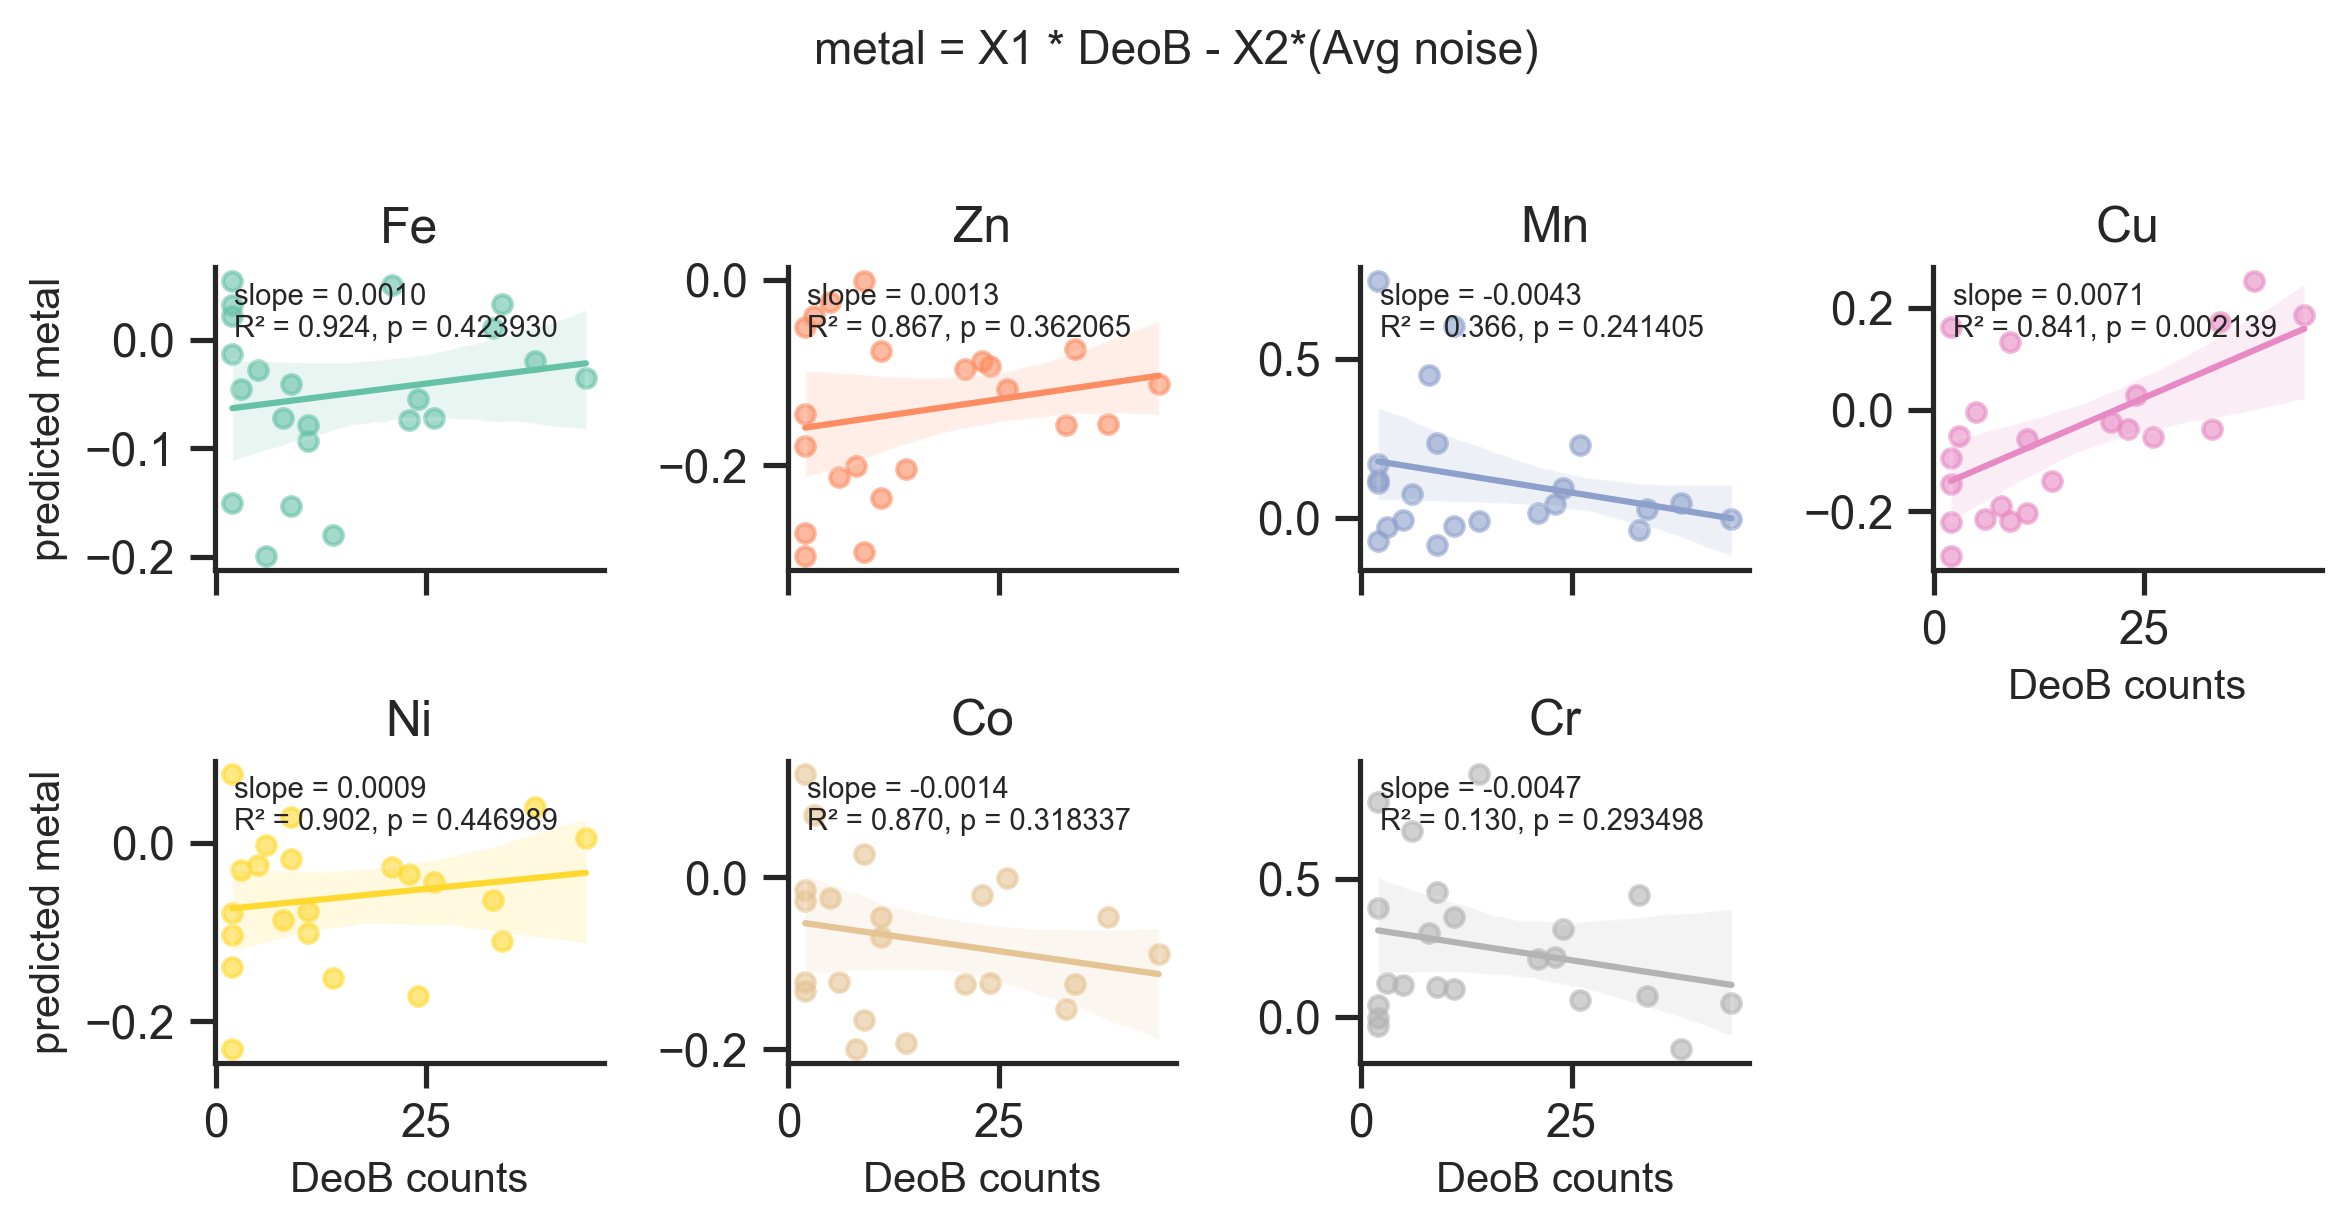

In [39]:
# Prepare data for all elements
plot_data_list = []
slopes = []
slope_ses = []
stats_dict = {}

for elem in element_order:
    df_pd = pivot_norm_all.select([gene, "avg_signal", elem]).to_pandas()
    df_pd.columns = ["DeoB", "avg_signal", "metal"]

    X = df_pd[["DeoB", "avg_signal"]].values
    y = df_pd["metal"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    X1, X2 = model.coef_

    # SE of X1 from multiple regression covariance matrix
    n, p = X.shape
    residuals = y - y_pred
    MSE = np.sum(residuals ** 2) / (n - p - 1)
    X_aug = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    SE_X1 = np.sqrt(MSE * XtX_inv[1, 1])

    slopes.append(X1)
    slope_ses.append(SE_X1)

    metal_corrected = y - X2 * df_pd["avg_signal"].values
    _, _, r_c, p_c, _ = stats.linregress(df_pd["DeoB"].values, metal_corrected)

    # Store stats for annotation
    stats_dict[elem] = {"X1": X1, "r2": r2, "p_c": p_c}
    
    # Build combined dataframe
    plot_df = pd.DataFrame({
        "DeoB": df_pd["DeoB"], 
        "metal_corrected": metal_corrected,
        "Element": elem
    })
    plot_data_list.append(plot_df)

# Combine all data
combined_plot_data = pd.concat(plot_data_list, ignore_index=True)

# Create the lmplot
g = sns.lmplot(x="DeoB", y="metal_corrected", hue="Element", data=combined_plot_data,
               height=2.0, aspect=1,
               col="Element", col_order=element_order, col_wrap=4,
               sharey=False, palette=element_palette,
               scatter_kws={"alpha": 0.6, "s": 20},
               line_kws={"linewidth": 1.5, "linestyle": "-"},
               legend=False)

# Annotation function
def annotate_stats(data, **kws):
    ax = plt.gca()
    elem = data["Element"].iloc[0]
    stats_info = stats_dict[elem]
    ax.text(0.05, 0.95,
            f"slope = {stats_info['X1']:.4f}\nR² = {stats_info['r2']:.3f}, p = {stats_info['p_c']:5f}",
            transform=ax.transAxes, fontsize=7, va="top")

# Apply annotations
g.map_dataframe(annotate_stats)

# Adjust labels
g.set_axis_labels("DeoB counts", "predicted metal", fontsize=10)
g.set_titles("{col_name}", fontsize=10)

# Add suptitle
g.figure.suptitle("metal = X1 * DeoB - X2*(Avg noise)", fontsize=11, y=1.02)

# Save and show
sns.despine()
plt.tight_layout()
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_lr_avgAll_signal.svg", 
#             format="svg", bbox_inches="tight")
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_lr_avgAll_signal.png", 
#             format="png", bbox_inches="tight")
plt.show()

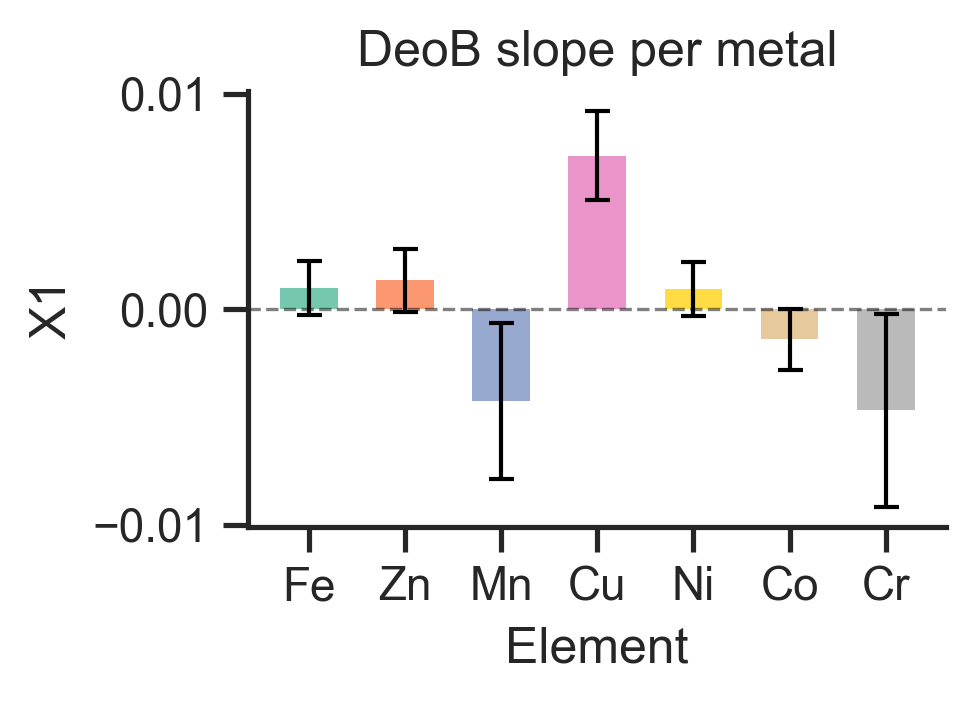

In [40]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

bar_colors = [element_palette[elem] for elem in element_order]
x_pos = np.arange(len(element_order))

ax.bar(x_pos, slopes, color=bar_colors, width=0.6, alpha=0.9,
       edgecolor="none")
ax.errorbar(x_pos, slopes, yerr=slope_ses,
            fmt="none", color="black", capsize=3, lw=1)
ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(element_order)
ax.set_xlabel("Element")
ax.set_ylabel("X1")
ax.set_title("DeoB slope per metal")

sns.despine()
plt.tight_layout()
# plt.savefig(f"/Users/adrianjuarez/Documents/Covert_lab/projects/Metals/DeoB_figures/{gene}_metal_slopes_barplotAll.svg", format="svg", bbox_inches="tight")
plt.show()

# begin RNA seq work here 

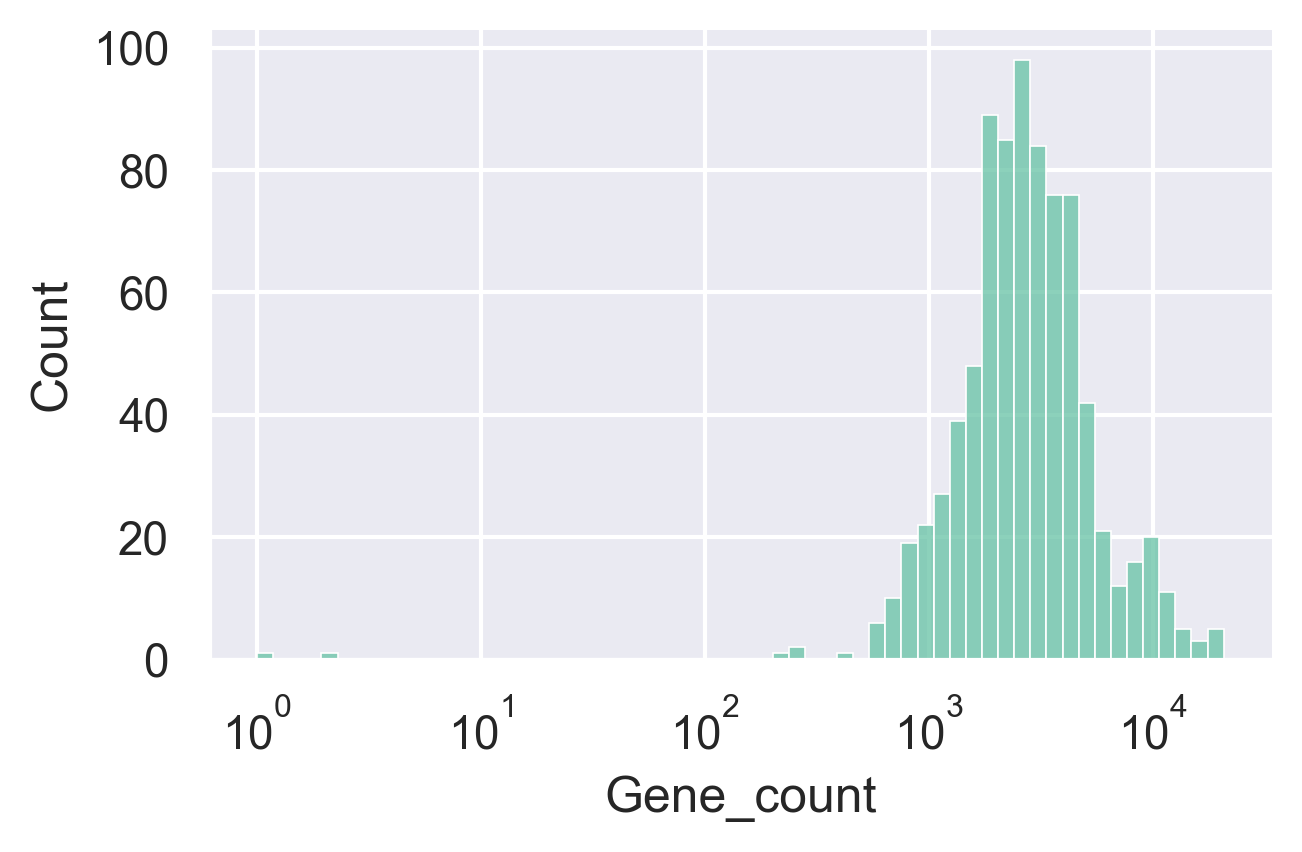

In [41]:
sns.set(style="ticks", palette="Set2", context="notebook", rc={'axes.formatter.limits': (-3, 3)})
warnings.filterwarnings(action='ignore')

GENE_INFO_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/gene_info.csv"
GENE_ID = "b4383"

m = pl.read_csv("/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/metadata.tsv", separator="\t")
d = pl.read_csv("/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/counts.csv")
gene_info = pl.read_csv(GENE_INFO_PATH)
cols = ['Experiment', 'study', 'condition_id', 'rep_id', 'creator', 'run_date', 'Strain Description', 
 'Base Media', 'Carbon Source (g/L)', 'Nitrogen Source (g/L)', 'Electron Acceptor', 'Trace Element Mixture', 
 'Supplement', 'Temperature (C)', 'pH', 'Growth Rate (1/hr)']

sns.set(style="darkgrid", palette="Set2")

pl.Config(tbl_rows=30)
# melt data
dm = d.melt(id_vars="Geneid", variable_name="Experiment", value_name="Gene_count")
dj = dm.join(m, on="Experiment", how="left", coalesce=True)

cols = ['Experiment', 'Geneid', 'Gene_count', 'study', 'condition_id', 'rep_id', 'creator', 'run_date', 'Strain Description', 
 'Base Media', 'Carbon Source (g/L)', 'Nitrogen Source (g/L)', 'Electron Acceptor', 'Trace Element Mixture', 
 'Supplement', 'Temperature (C)', 'pH', 'Growth Rate (1/hr)']

dj.select(cols)
sns.displot(x='Gene_count', height = 3, aspect = 1.5, data = dj.filter(pl.col('Geneid')==GENE_ID).to_pandas(), 
            log_scale=[10,False],  common_norm=False, legend=True)

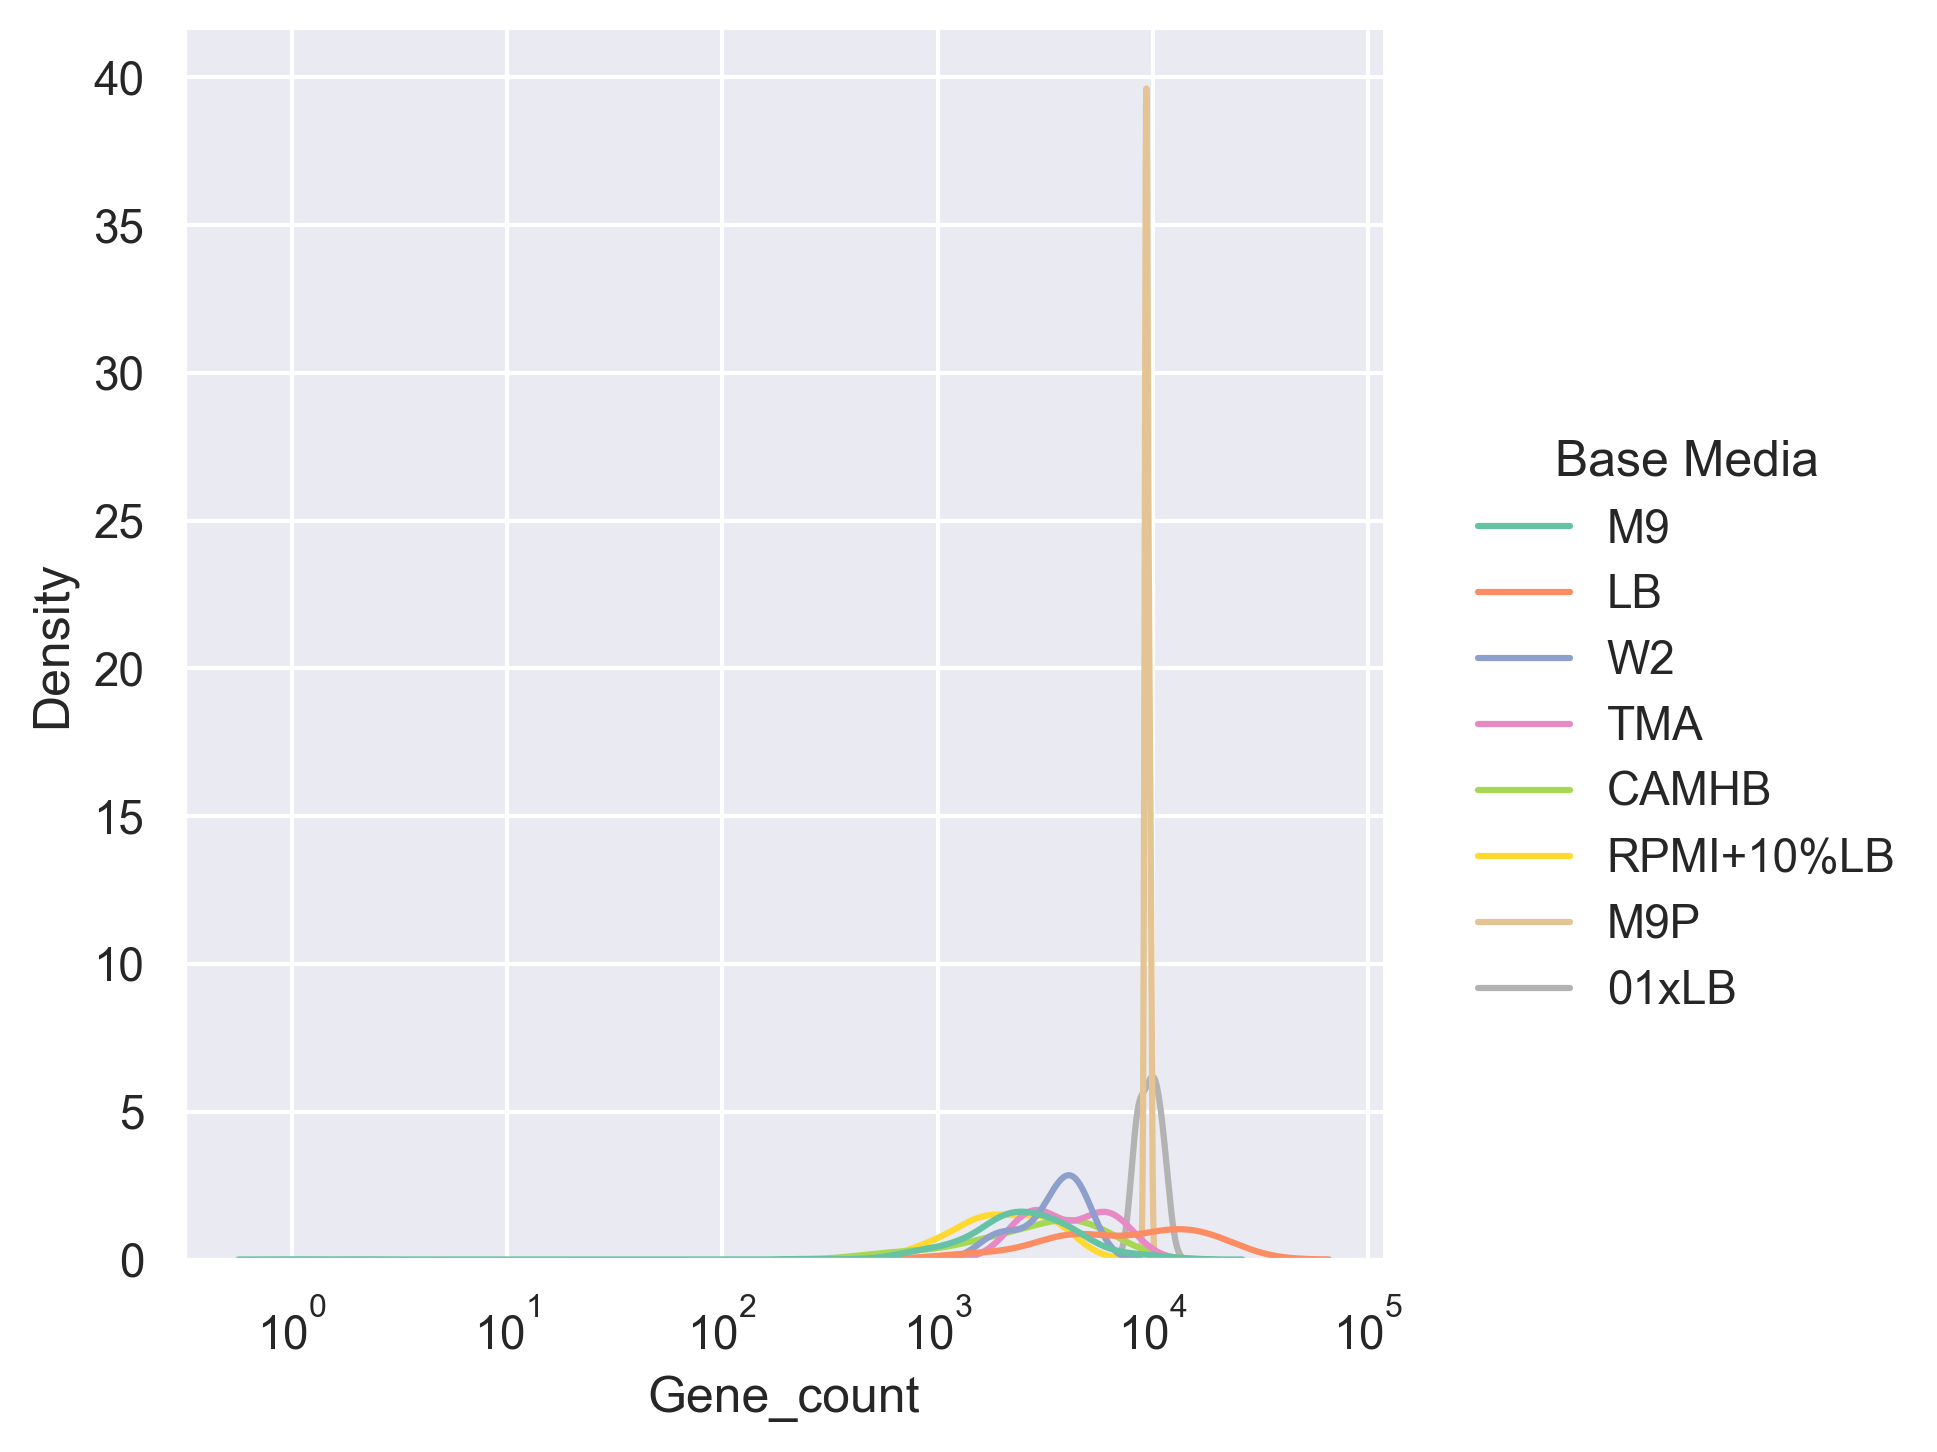

In [42]:
sns.displot(x='Gene_count', data = dj.filter(pl.col('Geneid')==GENE_ID).to_pandas(), 
            kind='kde', log_scale=[10,False], hue='Base Media', common_norm=False)

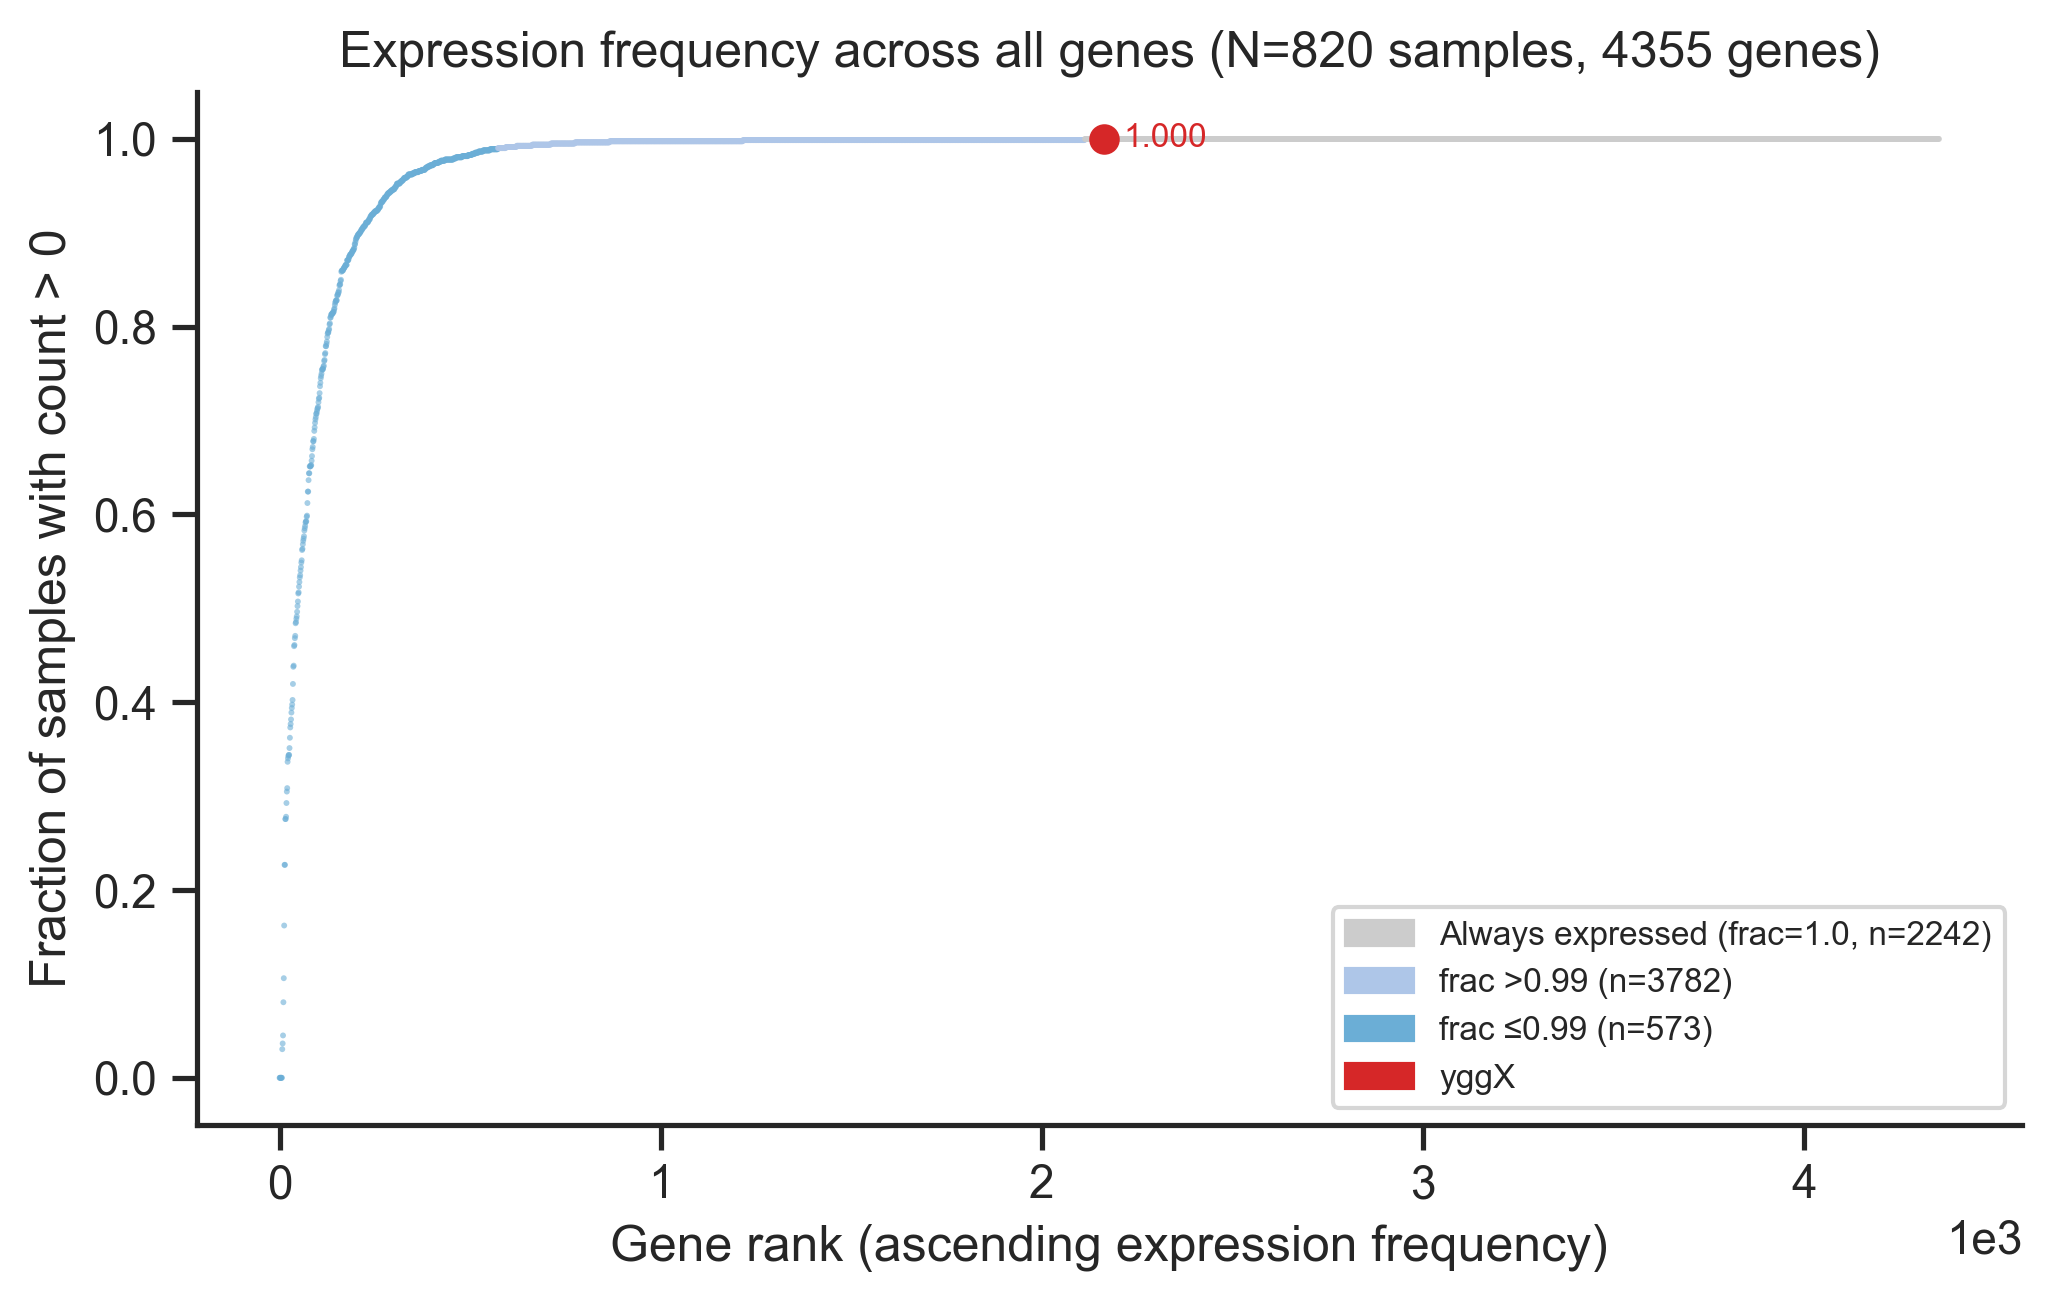

In [ ]:
COUNTS_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/counts.csv"
import matplotlib.patches as mpatches

sns.set(style="ticks", palette="Set2", context="notebook",
        rc={"axes.formatter.limits": (-3, 3)})
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

d = pl.read_csv(COUNTS_PATH)
count_cols = d.columns[1:]
expr_matrix = d.select(count_cols).to_numpy()
gene_ids = d["Geneid"].to_list()

frac_expressed = (expr_matrix > 0).mean(axis=1)

DeoB_idx = gene_ids.index(GENE_ID)
DeoB_frac = frac_expressed[DeoB_idx]

sort_order = np.argsort(frac_expressed)
DeoB_rank = int(np.where(sort_order == DeoB_idx)[0][0])
n_genes = len(frac_expressed)
frac_sorted = frac_expressed[sort_order]

fig, ax = plt.subplots(figsize=(7, 4.5))

colors = np.where(frac_sorted == 1.0, "#cccccc",
        np.where(frac_sorted > 0.99, "#aec6e8", "#6baed6"))
ax.scatter(np.arange(n_genes), frac_sorted, c=colors, s=2, alpha=0.6,
            linewidths=0, rasterized=True)

ax.scatter(DeoB_rank, DeoB_frac, color="#d62728", s=40, zorder=5)
ax.text(DeoB_rank + 50, DeoB_frac, f"{DeoB_frac:.3f}",
        fontsize=8, color="#d62728", va="center")

legend_patches = [
    mpatches.Patch(color="#cccccc", label=f"Always expressed (frac=1.0, n={(frac_expressed==1.0).sum()})"),
    mpatches.Patch(color="#aec6e8", label=f"frac >0.99 (n={(frac_expressed>0.99).sum()})"),
    mpatches.Patch(color="#6baed6", label=f"frac ≤0.99 (n={(frac_expressed<=0.99).sum()})"),
    mpatches.Patch(color="#d62728", label="DeoB"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="lower right")
ax.set_xlabel("Gene rank (ascending expression frequency)")
ax.set_ylabel("Fraction of samples with count > 0")
ax.set_title(f"Expression frequency across all genes (N=820 samples, {n_genes} genes)")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("DeoB_expression_frequency_rank.pdf", bbox_inches="tight")
plt.show()

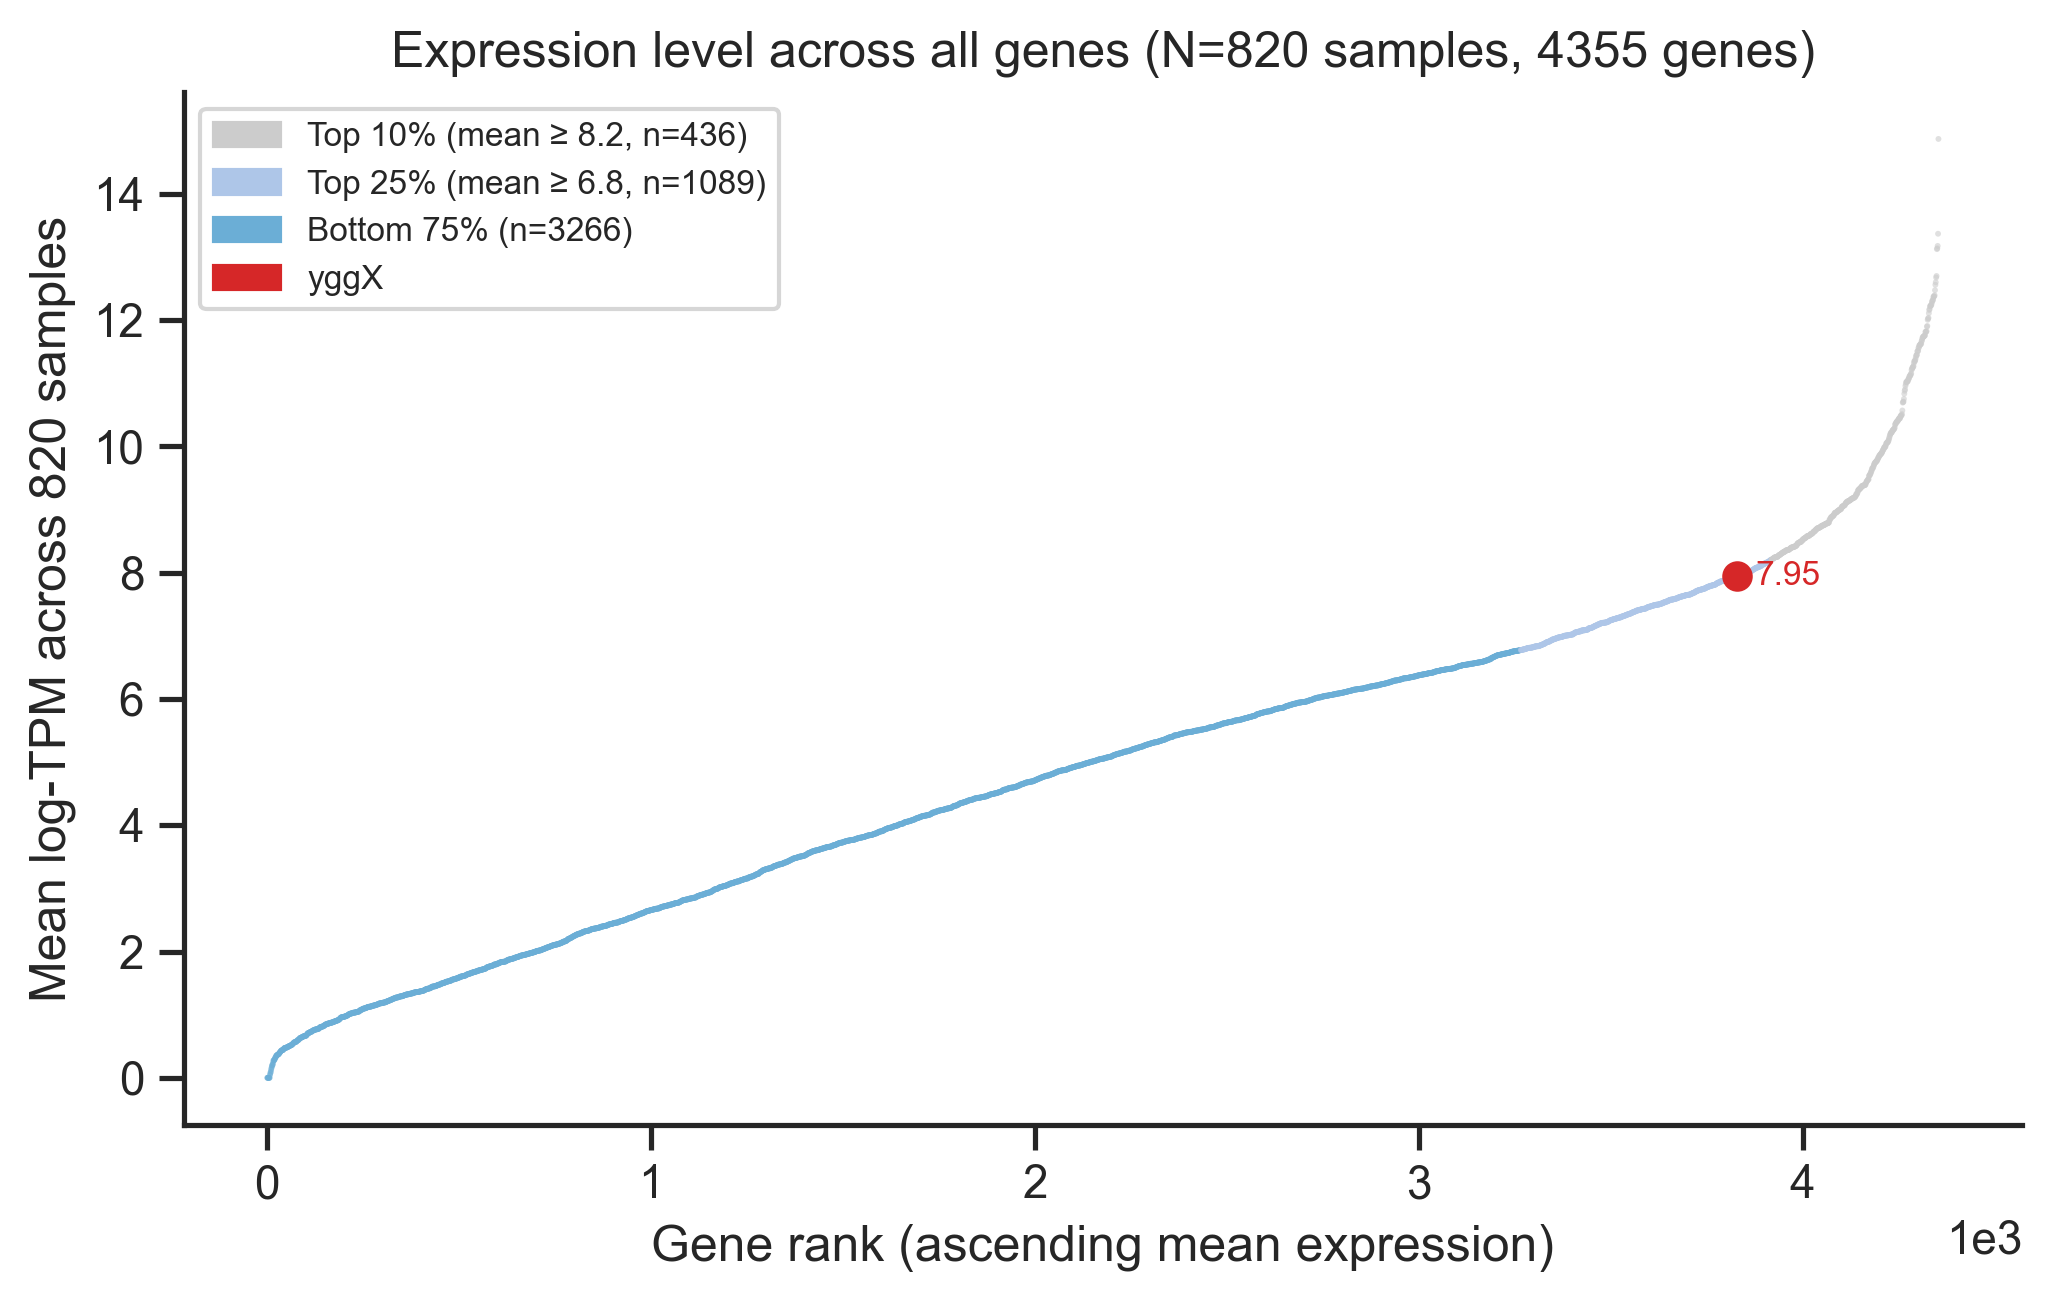

In [ ]:
LOG_TPM_PATH = "/Users/adrianjuarez/Documents/Covert_lab/repos/precise2/data/precise2/log_tpm.csv"

sns.set(style="ticks", palette="Set2", context="notebook",
        rc={"axes.formatter.limits": (-3, 3)})
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

d = pl.read_csv(LOG_TPM_PATH)
count_cols = d.columns[1:]
expr_matrix = d.select(count_cols).to_numpy()
gene_ids = d["Geneid"].to_list()

mean_expr = expr_matrix.mean(axis=1)  # mean log-TPM across all 820 samples

DeoB_idx = gene_ids.index(GENE_ID)
DeoB_mean = mean_expr[DeoB_idx]

sort_order = np.argsort(mean_expr)
DeoB_rank = int(np.where(sort_order == DeoB_idx)[0][0])
n_genes = len(mean_expr)
mean_sorted = mean_expr[sort_order]

# Colour tiers by expression level
p75 = np.percentile(mean_expr, 75)
p90 = np.percentile(mean_expr, 90)

colors = np.where(mean_sorted >= p90, "#cccccc",
        np.where(mean_sorted >= p75, "#aec6e8", "#6baed6"))

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(np.arange(n_genes), mean_sorted, c=colors, s=2, alpha=0.6,
            linewidths=0, rasterized=True)

ax.scatter(DeoB_rank, DeoB_mean, color="#d62728", s=40, zorder=5)
ax.text(DeoB_rank + 50, DeoB_mean, f"{DeoB_mean:.2f}",
        fontsize=8, color="#d62728", va="center")

legend_patches = [
    mpatches.Patch(color="#cccccc", label=f"Top 10% (mean ≥ {p90:.1f}, n={int((mean_expr>=p90).sum())})"),
    mpatches.Patch(color="#aec6e8", label=f"Top 25% (mean ≥ {p75:.1f}, n={int((mean_expr>=p75).sum())})"),
    mpatches.Patch(color="#6baed6", label=f"Bottom 75% (n={int((mean_expr<p75).sum())})"),
    mpatches.Patch(color="#d62728", label="DeoB"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="upper left")
ax.set_xlabel("Gene rank (ascending mean expression)")
ax.set_ylabel("Mean log-TPM across 820 samples")
ax.set_title(f"Expression level across all genes (N=820 samples, {n_genes} genes)")
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("DeoB_expression_level_rank.pdf", bbox_inches="tight")
plt.show()